<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ЛАБОРАТОРНА РОБОТА 11: Модель SEIR. Чуркін Дмитро ФІТ 3-15

Був присутній на парі

Практичні завдання: Моделювання поширення COVID-19 в Україні (квітень, 2020 рік). За прогнозом Національної медичної академії наук COVID-19 можуть перехворіти 20 млн українців. Приймемо цю величину в якості розміру популяції. Середнє число контактів хворої людини становить 2 людини в день. Ймовірність зараження дорівнює 0,5. За даними МЗС, в березні 2020 року в Україні повернулося 270000 людей. Припустимо, що 0,1% з них вже хворіють і можуть заражати. Таким чином, на початку епідемії хворіє 270 осіб. За даними Всесвітньої організації здоров'я, тривалість інкубаційного періоду COVID-19 коливається в межах від 1 до 14 днів, і найбільш ймовірне значення становить 5 днів. Тобто в середньому через 5 днів з'являються перші симптоми. Після появи перших симптомів людина починає заражати інших людей. Тривалість хвороби від появи перших симптомів до одужання коливається в межах від 10 до 30 днів, і найбільш ймовірне значення становить 22 дня.

Сценарій 1. Уряд нічого не робить За допомогою моделі зробіть прогноз наступних показників: максимальне число одночасно хворих. в який день (± 3 дні) буде максимум хворих. в який день (± 3 дні) число одужалих досягне 15 млн. Збережіть модель під ім'ям SEIR1. Щоб знизити максимальну кількість одночасно хворих, уряд вводить карантин. Мета карантину – скоротити число контактів між хворими та здоровими. Приймемо, що карантин ввели 1 березня. Зробіть той же прогноз в умовах карантину. Розгляньте чотири варіанти зниження числа контактів (1.5, 1, 0.5, 0.4). Збережіть модель під ім'ям SEIR1.

Сценарій 2. Уряд вводить карантин Основна небезпека COVID-19 полягає у відсутності імунітету і тривалому періоді зараження (до 30 днів). Якби люди активно заражали лише 3-5 днів, як при звичайному грипі, то ніякої пандемії би не було. Щоб знизити максимальну кількість одночасно хворих, уряд вводить карантин. Мета карантину – скоротити число контактів між хворими та здоровими. Приймемо, що карантин ввели 1 березня. Зробіть той же прогноз в умовах карантину. Розгляньте чотири варіанти зниження числа контактів (1.5, 1, 0.5, 0.4). Збережіть модель під ім'ям SEIR2.

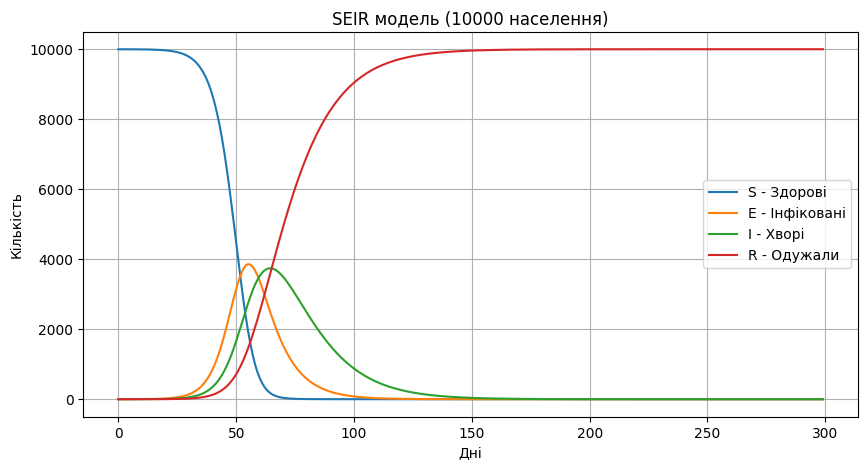

БЕЗ КАРАНТИНУ
Макс хворих: 11939468
День піку: 43
15 млн одужалих на день: 68


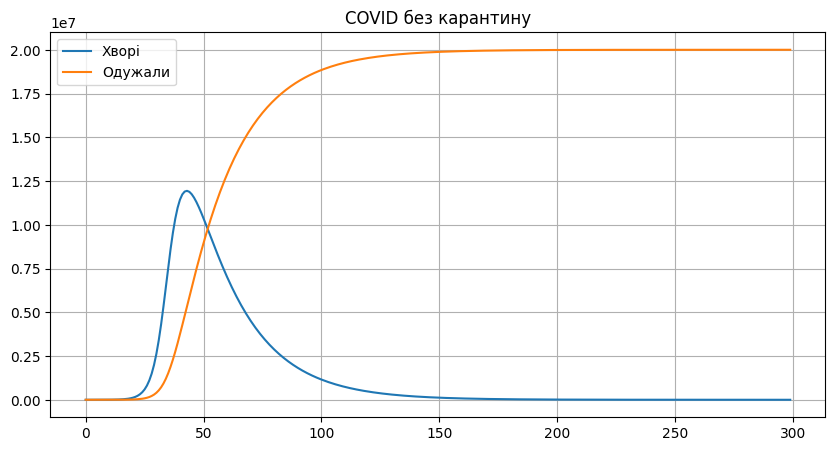


 КАРАНТИН contacts=1.5
Макс хворих: 11500365
День піку: 51

 КАРАНТИН contacts=1
Макс хворих: 10593819
День піку: 66

 КАРАНТИН contacts=0.5
Макс хворих: 8059115
День піку: 111

 КАРАНТИН contacts=0.4
Макс хворих: 6967538
День піку: 135


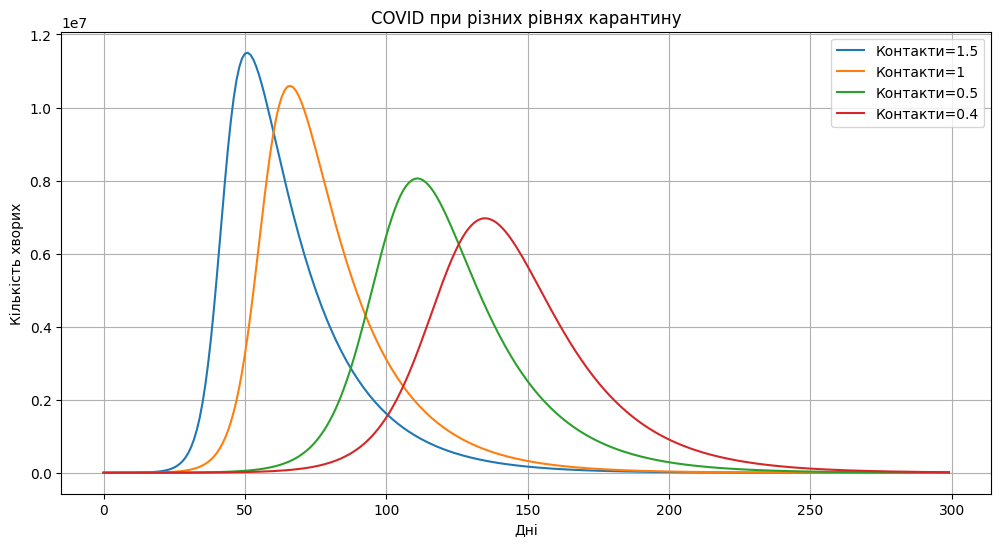

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ЧАСТИНА 1 — БАЗОВА SEIR МОДЕЛЬ (10000 населення)

N = 10000
beta = 0.6
Ke = 1.25
Inc_t = 10
Dur_ill = 15

alpha = 1 / Inc_t
gamma = 1 / Dur_ill

days = 300

S0 = N - 1
E0 = 1
I0 = 0
R0 = 0

def seir_basic(t, y):
    S, E, I, R = y

    dS = -beta * Ke * S * I / N
    dE = beta * Ke * S * I / N - alpha * E
    dI = alpha * E - gamma * I
    dR = gamma * I

    return [dS, dE, dI, dR]

sol = solve_ivp(
    seir_basic,
    [0, days],
    [S0, E0, I0, R0],
    t_eval=np.arange(0, days, 1)
)

plt.figure(figsize=(10,5))
plt.plot(sol.t, sol.y[0], label="S - Здорові")
plt.plot(sol.t, sol.y[1], label="E - Інфіковані")
plt.plot(sol.t, sol.y[2], label="I - Хворі")
plt.plot(sol.t, sol.y[3], label="R - Одужали")
plt.title("SEIR модель (10000 населення)")
plt.xlabel("Дні")
plt.ylabel("Кількість")
plt.legend()
plt.grid()
plt.show()

# ЧАСТИНА 2 — COVID В УКРАЇНІ БЕЗ КАРАНТИНУ

N2 = 20000000
contacts = 2
prob = 0.5
beta2 = contacts * prob

Inc_t2 = 5
Dur_ill2 = 22

alpha2 = 1 / Inc_t2
gamma2 = 1 / Dur_ill2

S0 = N2 - 270
E0 = 0
I0 = 270
R0 = 0

def covid_no_quarantine(t, y):
    S, E, I, R = y

    dS = -beta2 * S * I / N2
    dE = beta2 * S * I / N2 - alpha2 * E
    dI = alpha2 * E - gamma2 * I
    dR = gamma2 * I

    return [dS, dE, dI, dR]

sol2 = solve_ivp(
    covid_no_quarantine,
    [0, 300],
    [S0, E0, I0, R0],
    t_eval=np.arange(0,300,1)
)

peak_I = max(sol2.y[2])
peak_day = np.argmax(sol2.y[2])

day_15m = np.argmax(sol2.y[3] >= 15000000)

print("БЕЗ КАРАНТИНУ")
print("Макс хворих:", int(peak_I))
print("День піку:", peak_day)
print("15 млн одужалих на день:", day_15m)

plt.figure(figsize=(10,5))
plt.plot(sol2.t, sol2.y[2], label="Хворі")
plt.plot(sol2.t, sol2.y[3], label="Одужали")
plt.title("COVID без карантину")
plt.legend()
plt.grid()
plt.show()

# ЧАСТИНА 3 — КАРАНТИН

quarantine_contacts = [1.5, 1, 0.5, 0.4]

plt.figure(figsize=(12,6))

for c in quarantine_contacts:

    beta_q = c * prob

    def covid_quarantine(t, y):
        S, E, I, R = y

        dS = -beta_q * S * I / N2
        dE = beta_q * S * I / N2 - alpha2 * E
        dI = alpha2 * E - gamma2 * I
        dR = gamma2 * I

        return [dS, dE, dI, dR]

    sol_q = solve_ivp(
        covid_quarantine,
        [0,300],
        [S0,E0,I0,R0],
        t_eval=np.arange(0,300,1)
    )

    plt.plot(sol_q.t, sol_q.y[2], label=f"Контакти={c}")

    peak = max(sol_q.y[2])
    peak_day = np.argmax(sol_q.y[2])

    print(f"\n КАРАНТИН contacts={c}")
    print("Макс хворих:", int(peak))
    print("День піку:", peak_day)

plt.title("COVID при різних рівнях карантину")
plt.xlabel("Дні")
plt.ylabel("Кількість хворих")
plt.legend()
plt.grid()
plt.show()